<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/May2026/26MayConvNeXt_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using Device: cuda
Classes: ['0', '1', '2', '3', '4', '5']
Number of Classes: 6
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 126MB/s]


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

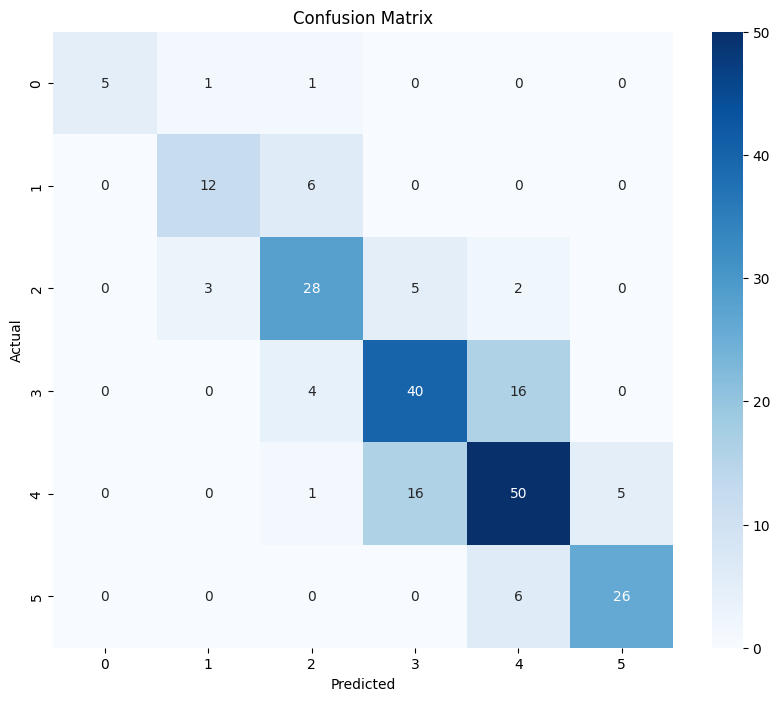

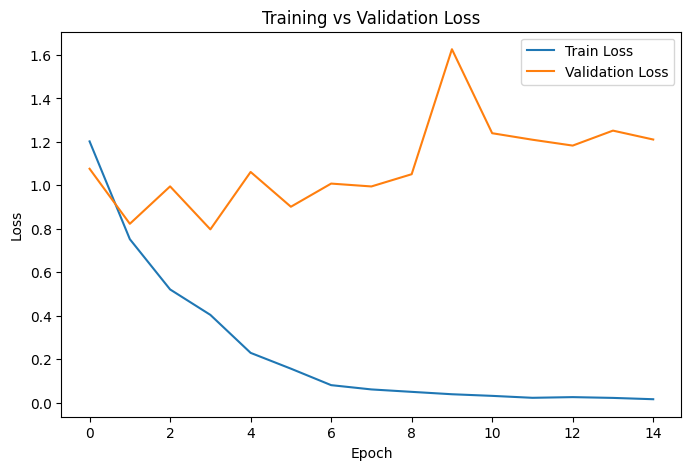


Extracting Features for t-SNE...
Feature Shape: (227, 768)
Running t-SNE...
t-SNE Completed


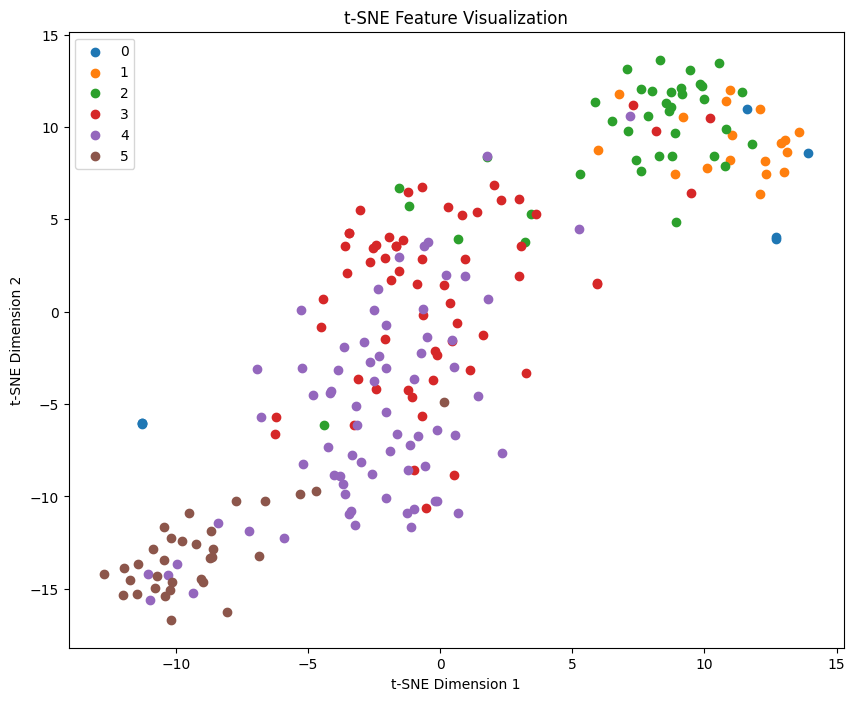


Model Saved Successfully!

Saved Files:
1. best_convnext_model.pth
2. final_convnext_model.pth


In [2]:
import os
import copy
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms, datasets
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE


# =========================================================
# PATHS
# =========================================================

train_dir = "/content/drive/MyDrive/ResearchData/May2026/TrainVsTest1118images/train"
val_dir   = "/content/drive/MyDrive/ResearchData/May2026/TrainVsTest1118images/val"


# =========================================================
# CONFIG
# =========================================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)


# =========================================================
# DATASET
# =========================================================

NUM_CLASSES = len(os.listdir(train_dir))

train_transforms = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize([0.5]*3, [0.5]*3)

])

val_transforms = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize([0.5]*3, [0.5]*3)

])


# =========================================================
# LOAD DATASET
# =========================================================

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Number of Classes:", NUM_CLASSES)


# =========================================================
# MODEL
# =========================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

# Replace classifier layer
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model)


# =========================================================
# LOSS + OPTIMIZER
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)


# =========================================================
# TRAINING
# =========================================================

best_acc = 0.0

train_losses = []
val_losses = []

best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    print("\n" + "="*50)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*50)

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)

    val_losses.append(val_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Accuracy   : {acc:.4f}")

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if acc > best_acc:

        best_acc = acc

        best_model_wts = copy.deepcopy(model.state_dict())

        torch.save(
            model.state_dict(),
            "best_convnext_model.pth"
        )

        print("Best Model Saved!")

    scheduler.step()


# =========================================================
# LOAD BEST MODEL
# =========================================================

model.load_state_dict(best_model_wts)

print("\nBest Validation Accuracy:", best_acc)


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()


# =========================================================
# t-SNE FEATURE VISUALIZATION
# =========================================================

print("\nExtracting Features for t-SNE...")

model.eval()

features = []
labels_list = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        # Feature extraction
        x = model.features(images)

        # Global Average Pooling
        x = model.avgpool(x)

        x = torch.flatten(x, 1)

        features.append(x.cpu().numpy())

        labels_list.extend(labels.numpy())

# Convert to numpy
features = np.concatenate(features, axis=0)

labels_list = np.array(labels_list)

print("Feature Shape:", features.shape)


# =========================================================
# APPLY t-SNE
# =========================================================

print("Running t-SNE...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

tsne_features = tsne.fit_transform(features)

print("t-SNE Completed")


# =========================================================
# PLOT t-SNE
# =========================================================

plt.figure(figsize=(10,8))

for class_idx in range(NUM_CLASSES):

    idxs = labels_list == class_idx

    plt.scatter(
        tsne_features[idxs, 0],
        tsne_features[idxs, 1],
        label=class_names[class_idx]
    )

plt.legend()

plt.title("t-SNE Feature Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()


# =========================================================
# SAVE FINAL MODEL
# =========================================================

torch.save(model.state_dict(), "final_convnext_model.pth")

print("\nModel Saved Successfully!")

print("\nSaved Files:")
print("1. best_convnext_model.pth")
print("2. final_convnext_model.pth")